In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

/Users/Ram/Desktop/Mtech/unifize/.venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [3]:
class AgentState(TypedDict):
    number1: int
    number2: int
    number3: int
    number4: int
    operation: str
    operation2: str
    finalNumber: int
    finalNumber2: int

In [4]:
# for first pair (number1, number2)
def adder1(state: AgentState) -> AgentState:
    """Add number1 and number2, and store the result in finalNumber."""
    state["finalNumber"] = state["number1"] + state["number2"]
    return state

def subtractor1(state: AgentState) -> AgentState:
    """Subtract number2 from number1, and store the result in finalNumber."""
    state["finalNumber"] = state["number1"] - state["number2"]
    return state

def adder2(state:AgentState)-> AgentState:
    """Add number3 and number4, and store the result in finalNumber2."""
    state["finalNumber2"] = state["number3"] + state["number4"]
    return state

def subtractor2(state: AgentState)-> AgentState:
    """Subtract number4 from number3"""
    state["finalNumber2"]=state["number3"]-state["number4"]
    return state

defione router function

In [5]:
def router1(state: AgentState)-> str:
    """Route first pair based on operation"""
    if state["operation"]=="+":
        return "add1"
    elif state["operation"]=="-":
        return "subtract1"
    
def router2(state: AgentState)-> str:
    """Route second pair based on operation2"""
    if state["operation2"]=="+":
        return "add2"
    elif state["operation2"]=="-":
        return "subtract2"

build graph with conditional edges

In [9]:
graph= StateGraph(AgentState)

#Add all nodes
graph.add_node("router1", lambda state:state)
graph.add_node("add1", adder1)
graph.add_node("subtract1", subtractor1)
graph.add_node("router2", lambda state: state)  # ← ADD THIS LINE
graph.add_node("add2", adder2)
graph.add_node("subtract2", subtractor2)

#first path with conditional edge
graph.add_edge(START, "router1")
graph.add_conditional_edges(
    "router1",
    router1,
    {
        "add1": "add1",
        "subtract1": "subtract1"
    }
)

#Both routes lead to second router
graph.add_edge("add1", "router2")
graph.add_edge("subtract1", "router2")

#second path with conditional edge
graph.add_conditional_edges(
    "router2",
    router2,
    {
        "add2": "add2",
        "subtract2": "subtract2"
    }
)       

#Bothb routes enbd
graph.add_edge("add2", END)
graph.add_edge("subtract2", END)

app = graph.compile()

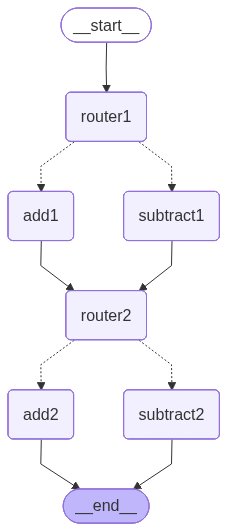

In [10]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [11]:
initial_state=AgentState(
    number1=10,
    number2=5,
    number3=20,
    number4=8,
    operation="+",
    operation2="-",
    finalNumber=0,
    finalNumber2=0
)
result=app.invoke(initial_state)
print(result)

{'number1': 10, 'number2': 5, 'number3': 20, 'number4': 8, 'operation': '+', 'operation2': '-', 'finalNumber': 15, 'finalNumber2': 12}
